In [314]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

# DADOS

In [315]:
df_dynamic = pd.read_csv('Analysis/DynamicTests/output.csv')
df_dynamic

,time,target_tmp,target_yaw,target_ax,target_roll,target_wx,target_wz,target_az,target_pitch,target_ay,target_wy,ref_la_pos_mon_d,ref_yaw,ref_ax,ref_wx,ref_roll,ref_q0,ref_wz,ref_az,ref_pitch,ref_wy,ref_ay,ref_q2,ref_sample_time,ref_q3,ref_q1
0,0.0,59.9,358.186,-0.877783,2.147,0.26370,0.23641,0.372859,-5.197,9.769365,0.09422,-0.04529,-27.226954,0.06865,0.001649,90.298149,0.6851,-0.004888,0.05025,0.269462,-0.027548,-9.788,-0.1652,5000000.0,-0.1676,0.6894
1,0.1,60.2,358.185,-0.920825,2.147,-0.10443,-0.33141,0.332681,-5.197,9.757254,-0.00270,-0.04534,-27.226954,0.06869,0.002540,90.298149,0.6851,-0.001643,0.05016,0.269290,-0.030676,-9.788,-0.1653,105000000.0,-0.1676,0.6894
2,0.2,59.9,358.185,-0.944125,2.146,0.14189,-0.37010,0.371721,-5.195,9.736817,0.10629,-0.04538,-27.232684,0.06863,-0.006262,90.298149,0.6851,-0.001564,0.04992,0.269061,-0.029272,-9.788,-0.1653,205000000.0,-0.1676,0.6894
3,0.3,59.9,358.185,-0.971633,2.147,0.20449,-0.62399,0.360561,-5.195,9.791842,0.14559,-0.04543,-27.232684,0.06853,-0.005907,90.298149,0.6851,0.003329,0.05004,0.269462,-0.022271,-9.789,-0.1653,305000000.0,-0.1677,0.6894
4,0.4,59.9,358.183,-0.892866,2.149,0.19343,-0.12722,0.350499,-5.196,9.751056,0.19675,-0.04547,-27.238414,0.06897,0.001729,90.298149,0.6851,0.002807,0.05005,0.269691,-0.029593,-9.788,-0.1653,405000000.0,-0.1677,0.6894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3156,315.6,60.2,1.185,-0.862142,2.072,-0.18226,-0.36127,0.343537,-5.040,9.764413,0.20174,0.22300,-28.877073,0.07978,-0.003453,90.298149,0.6829,-0.004904,0.04214,0.100096,-0.025416,-9.788,-0.1761,605000000.0,-0.1765,0.6866
3157,315.7,60.3,1.183,-0.894435,2.071,-0.12334,-0.05895,0.364837,-5.040,9.729707,0.16965,0.22330,-28.877073,0.07960,-0.006681,90.298149,0.6829,0.002209,0.04216,0.099637,-0.020432,-9.789,-0.1762,705000000.0,-0.1765,0.6866
3158,315.8,60.3,1.183,-0.812961,2.074,-0.29370,-0.25135,0.321295,-5.038,9.700395,0.29412,0.22360,-28.882802,0.07995,0.000197,90.298149,0.6829,0.001937,0.04192,0.099637,-0.024270,-9.788,-0.1762,805000000.0,-0.1765,0.6866
3159,315.9,60.2,1.183,-0.863436,2.073,0.26456,-0.12711,0.362464,-5.037,9.722685,0.01304,0.22390,-28.882802,0.08003,0.019813,90.298149,0.6829,0.013940,0.04169,0.099007,-0.015040,-9.788,-0.1762,905000000.0,-0.1765,0.6866


In [316]:
df_static = pd.read_csv('Analysis/StaticTests/output.csv')
df_static

,time,target_wx,target_tmp,target_wz,target_yaw,target_roll,target_az,target_wy,target_pitch,target_ax,target_ay,ref_wx,ref_wz,ref_yaw,ref_q1,ref_sample_time,ref_roll,ref_az,ref_q0,ref_q2,ref_la_pos_mon_d,ref_wy,ref_pitch,ref_ax,ref_q3,ref_ay
0,0.0,0.04551,60.2,0.12473,353.477,1.957,0.321011,0.35062,-4.358,-0.761653,9.788488,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.12805,-4.358,-0.778932,9.733845,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,0.2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,-0.20591,-4.359,-0.783649,9.778113,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.21019,-4.363,-0.683259,9.739553,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,0.4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,-0.02057,-4.360,-0.700028,9.725775,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,-0.03999,60.5,0.30606,353.194,1.976,0.305663,0.11702,-4.356,-0.767027,9.752674,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,67.0,-0.08075,60.5,-0.22989,353.193,1.975,0.371741,0.09941,-4.357,-0.707471,9.720430,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,67.1,-0.15441,60.5,0.45741,353.194,1.975,0.327993,-0.04488,-4.356,-0.752111,9.777936,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,67.2,0.03487,60.5,-0.18754,353.196,1.975,0.361601,0.35198,-4.355,-0.733381,9.739112,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,-0.018346,-0.251127,0.04204,-0.2545,-9.788


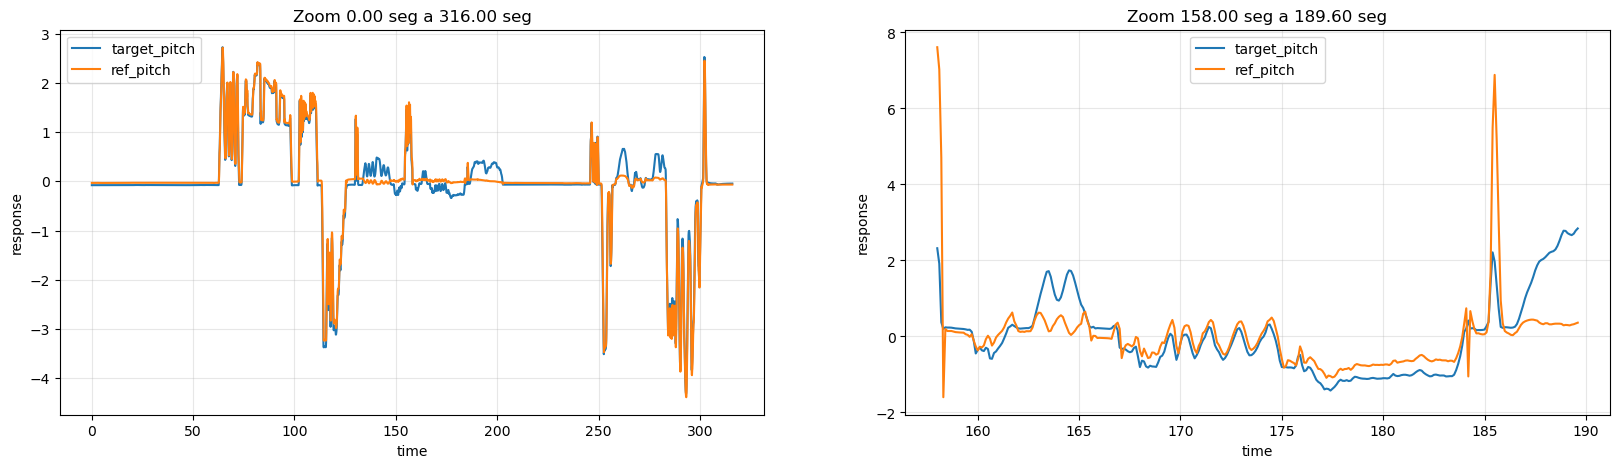

In [317]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target['target_' + varname] if not norm else normalize(target['target_' + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label='target_' + varname)
    plt.plot(target.time, values2, label='ref_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2)
plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))

# DEFASAGEM

In [318]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])
        
        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if abs(lag) < 2:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


phaser = Phaser('target_wz', 'ref_wz')
lag    = phaser.get(df_dynamic)
df_dynamic = phaser.set(df_dynamic, lag)
print('dynamic lag:', lag, 'samples')

phaser = Phaser('target_wz', 'ref_wz')
lag    = phaser.get(df_static)
df_static = phaser.set(df_static, lag)
print('static lag:', lag, 'samples')

dynamic lag: 1 samples
static lag: 108 samples


--------------------------------------------Dinamic Tests--------------------------------------------


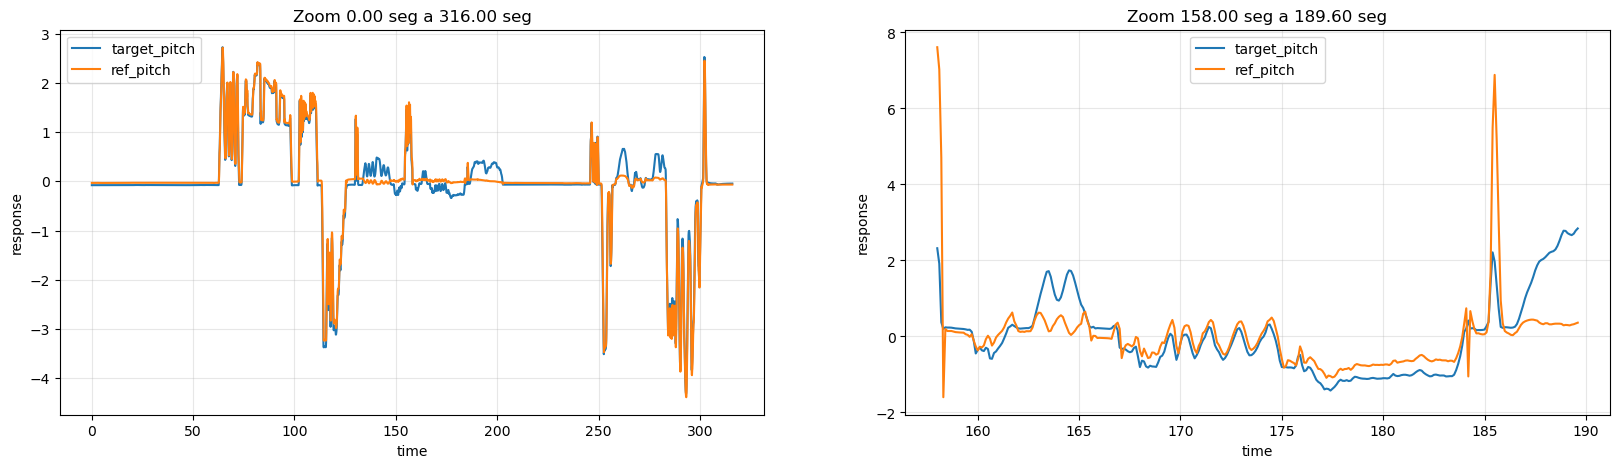

--------------------------------------------Static Tests--------------------------------------------


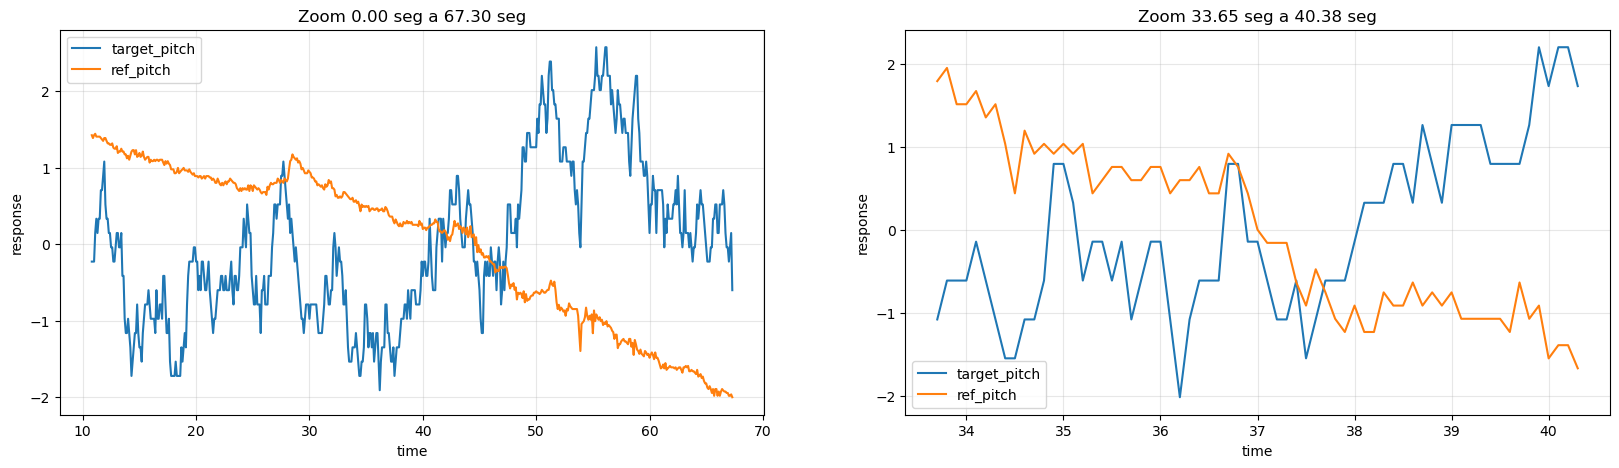

In [319]:
print('--------------------------------------------Dinamic Tests--------------------------------------------')
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, 'pitch', limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_dynamic,  'pitch', limits=(0.5, 0.6))
plt.show()

print('--------------------------------------------Static Tests--------------------------------------------')
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_static, 'pitch', limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, 'pitch', limits=(0.5, 0.6))
plt.show()

In [320]:
static_rms_roll = np.std(df_static['ref_roll'])
static_rms_pitch = np.std(df_static['ref_pitch'])

print(f"Ruído Estático da Kongsberg (Roll): {static_rms_roll:.4f} graus")
print(f"Ruído Estático da Kongsberg (Pitch): {static_rms_pitch:.4f} graus")

Ruído Estático da Kongsberg (Roll): 0.0000 graus
Ruído Estático da Kongsberg (Pitch): 0.0123 graus


# MODELO DE CALIBRAÇÃO

In [321]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [322]:
class TriaxialFit:
    def __init__(self, df, variables, time_col='time'):
        self.time = np.array(df[time_col])
        self.variables = variables
        
        self.X = np.column_stack([df[f'target_{var}'] for var in variables])
        self.Y = np.column_stack([df[f'ref_{var}']    for var in variables])
        
        self.M = np.eye(3)
        self.B = np.zeros(3)

        self.Y_model = np.zeros_like(self.Y)
        self.errors  = np.zeros_like(self.Y)
        self.metrics = {}

    def update(self):
        N = self.X.shape[0]
        X_aug = np.hstack((self.X, np.ones((N, 1))))
        W, _, _, _ = np.linalg.lstsq(X_aug, self.Y, rcond=None)
        
        self.M = W[:3, :].T
        self.B = W[3, :]
        self.Y_model = X_aug @ W
        self.errors  = self.Y - self.Y_model
        
        for i, axis in enumerate(self.variables):
            error  = self.errors[:, i]
            y_data = self.Y[:, i]
            
            rmse = np.sqrt(np.mean(error**2))
            mae  = np.mean(np.abs(error))
            max_error = np.max(np.abs(error))
            std_noise = error.std()
            
            ss_res = np.sum(error**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)
            
            self.metrics[axis] = {
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
                'max_error': max_error,
                'std_noise': std_noise,
                'bias': self.B[i],
                'scale_factor': self.M[i, i]
            }

    def display(self):
        matrix_df = pd.DataFrame(self.M, columns=self.variables, index=[f'{ax}_model' for ax in self.variables])
        matrix_df['bias'] = self.B
        display(matrix_df.style.format("{:.6f}"))

    def plot(self, axis_id, view_limits=None):
        axis_name = self.variables[axis_id]
        t_max     = self.time[-1]
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        
        t_plot = self.time[mask]
        y_plot = self.Y[mask, axis_id]
        mod_plot = self.Y_model[mask, axis_id]
        err_plot = self.errors[mask, axis_id]
        
        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='#6A3CBC', label='Reference', linewidth=2)
        plt.plot(t_plot, mod_plot, color='#E91E63', label='Model (Triaxial)', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'{axis_name}')
        plt.legend()
        plt.title(f'{axis_name.capitalize()} - R2 Score {self.metrics[axis_name]["r2"]:.3f}')
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='#6A3CBC')
        plt.xlabel('Time (s)')
        plt.ylabel('Error')
        plt.title(f'Temporal Error - Mean: {self.metrics[axis_name]["mae"]:.3f}')
        plt.grid(alpha=0.3)
        plt.show()

    def predict(self, axis):
        return self.Y_model[:, axis]

groups = {
    'Euler Angles': ['pitch', 'roll', 'yaw'],
    'Gyroscope': ['wx', 'wy', 'wz'],
    'Accelerometer': ['ax', 'ay', 'az']
}

,pitch,roll,yaw,bias
pitch_model,1.001871,0.079226,0.000070,5.263348
roll_model,-0.061955,1.028572,0.000499,87.442601
yaw_model,-0.066114,0.016966,-0.014464,-25.981143


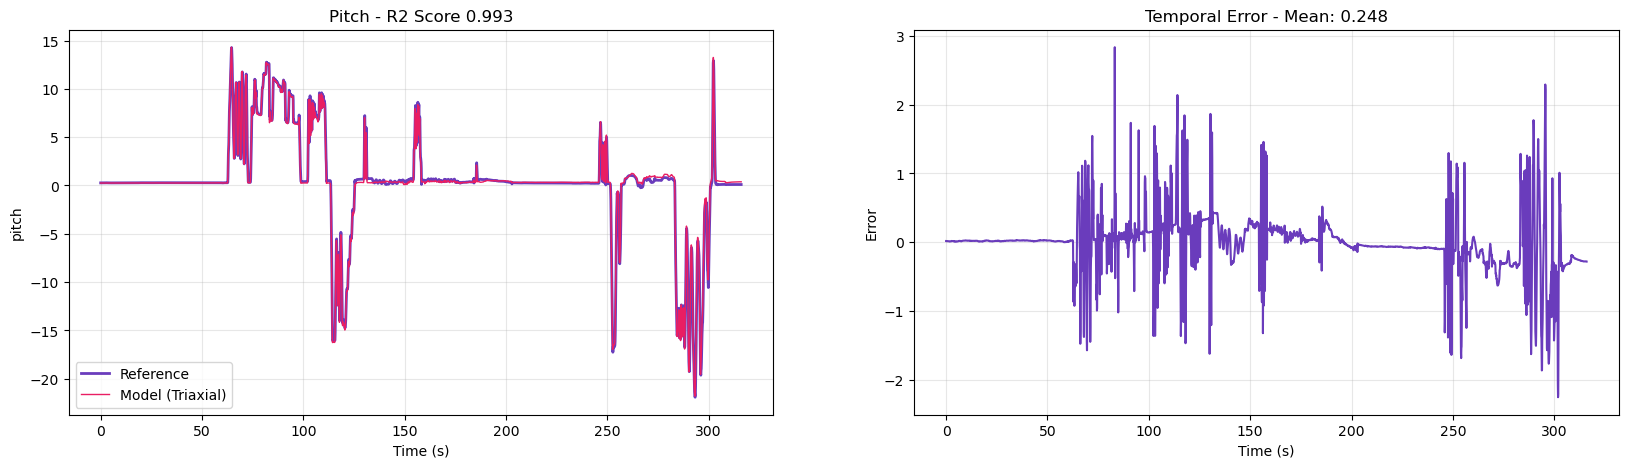

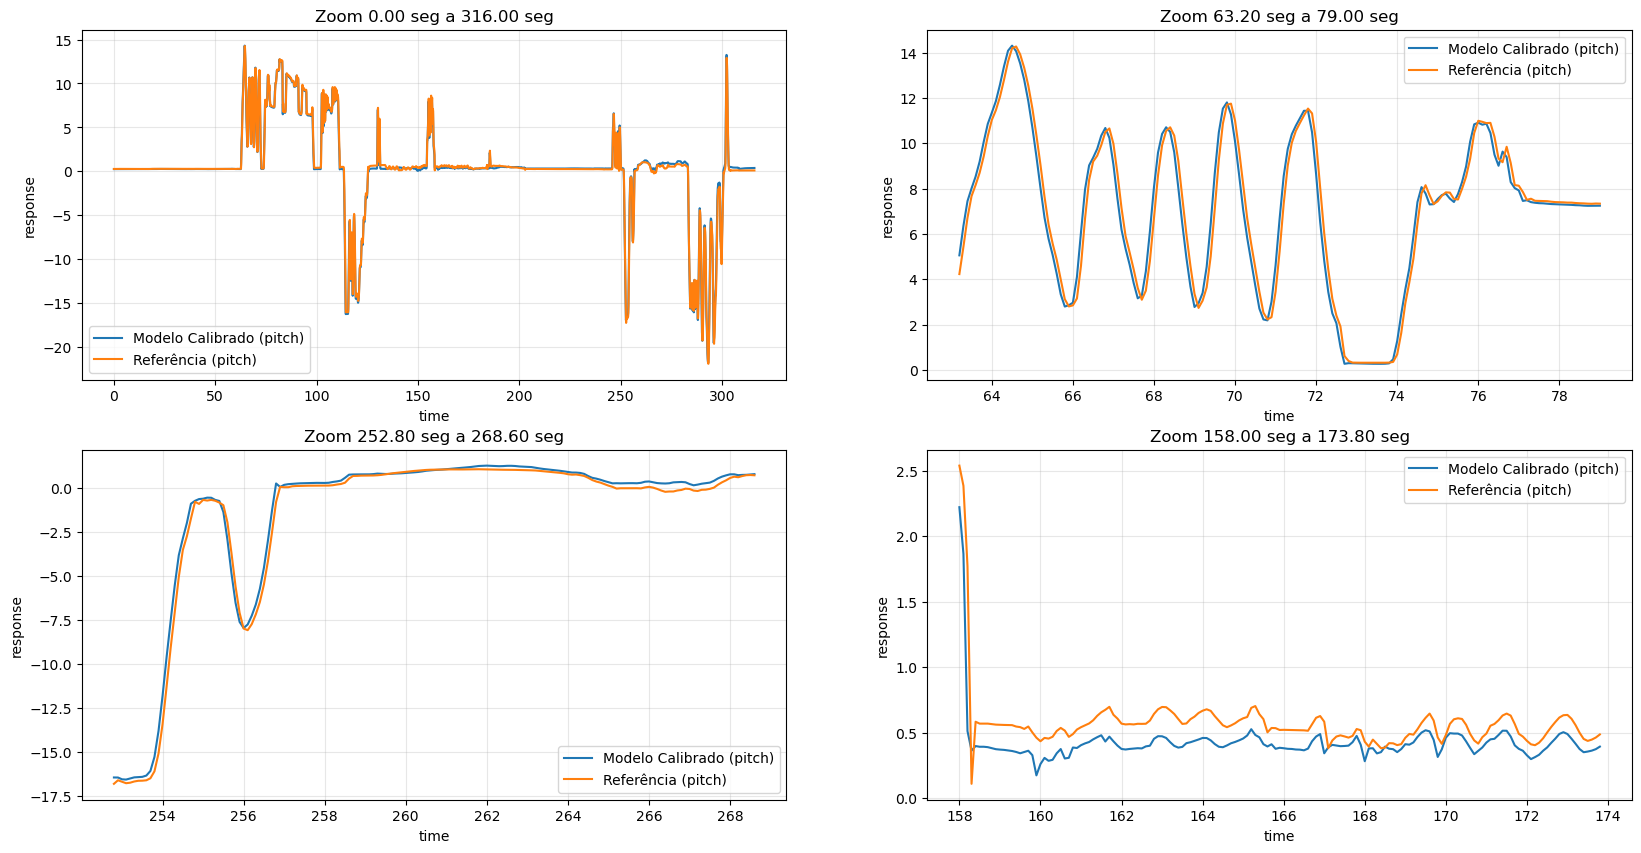

In [323]:
def plotModel(df, var, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]
    
    plt.plot(target.time, target['model_' + var], label=f'Modelo Calibrado ({var})')
    plt.plot(target.time, target['ref_' + var], label=f'Referência ({var})')
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f"Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}")


SPACING   = 0.05
VARIABLE  = 'pitch'
variables = [vars for vars in groups.values() if VARIABLE in vars][0]
idx = [i for i, vars in enumerate(groups.values()) if VARIABLE in vars][0]

model = TriaxialFit(df_dynamic, variables)
model.update()
model.display()
df_dynamic['model_' + VARIABLE] = model.predict(idx)

model.plot(idx, view_limits=(0, 1))
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1); plotModel(df_dynamic, VARIABLE, limits=(0, 1))
plt.subplot(2, 2, 2); plotModel(df_dynamic, VARIABLE, limits=(0.2, 0.2+SPACING))
plt.subplot(2, 2, 3); plotModel(df_dynamic, VARIABLE, limits=(0.8, 0.8+SPACING))
plt.subplot(2, 2, 4); plotModel(df_dynamic, VARIABLE, limits=(0.5, 0.5+SPACING))
plt.show()

In [ ]:
class CalibrationAnalysis:
    def __init__(self, model, df_dynamic, df_static, var):
        self.model = model
        self.df_dynamic = df_dynamic
        self.df_static  = df_static
        self.var = var

    def update(self):
        idx = self.model.variables.index(self.var)
        yRef_dyn = self.df_dynamic['ref_'   + self.var]
        yMod_dyn = self.df_dynamic['model_' + self.var]
        
        yRef_stat = self.df_static['ref_'    + self.var]
        yMod_stat = self.df_static['model_'  + self.var]
        yTgt_stat = self.df_static['target_' + self.var]

        err_dyn  = (yRef_dyn - yMod_dyn)
        err_stat = (yRef_stat - yMod_stat)

        accuracy_stat = np.max(np.abs(err_stat))
        
        rms_dyn  = np.sqrt(np.mean(err_dyn**2))
        rms_stat = np.sqrt(np.mean(err_stat**2))
        
        m  = self.model.metrics[self.var]
        r2 = m['r2']
        mae  = m['mae']
        rmse = m['rmse']

        tendencia = np.polyfit(self.df_static['time'], err_stat, 1)
        drift_por_segundo = tendencia[0]
        drift_por_hora    = drift_por_segundo * 3600
        
        self.metrics = {
            'r2': float(round(r2, 6)),
            'mae': float(round(mae, 6)),
            'rmse': float(round(rmse, 6)),
            'precision': float(round(2*np.std(err_stat), 6)),
            'max_error_stat': float(round(np.max(np.abs(err_stat)), 6)),
            'max_error_dyn': float(round(np.max(np.abs(err_dyn)), 6)),
            'rms_dyn': float(round(rms_dyn, 6)),
            'rms_stat': float(round(rms_stat, 6)),
            'std_stat': float(round(np.std(err_stat), 6)),
            'std_dyn': float(round(np.std(err_stat), 6)),
            'time_drift': float(round(drift_por_hora, 6))
        }

    def display(self):
        metrics = self.metrics.copy()
        del metrics['correctionMatrixRow']
        display(pd.DataFrame([metrics]))

# GERANDO RELATÓRIO

,pitch,roll,yaw,bias
pitch_model,1.001871,0.079226,0.000070,5.263348
roll_model,-0.061955,1.028572,0.000499,87.442601
yaw_model,-0.066114,0.016966,-0.014464,-25.981143


-------------------------------------------------------------------------------- pitch --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.992943,0.247848,0.428243,2.833569,1.001871,5.263348,0.032646,0.428243,1.307353,0.016323,2.833569,1.337198,-3.363611


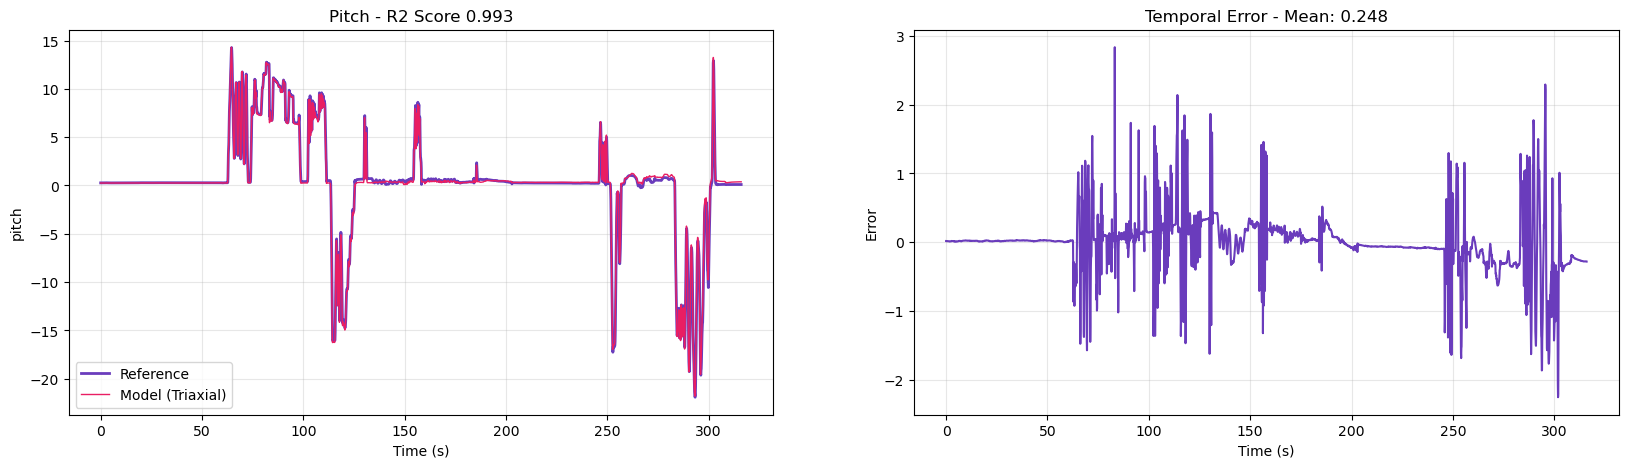

-------------------------------------------------------------------------------- roll --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.996562,0.321402,0.515746,2.941343,1.028572,87.442601,0.010318,0.515746,0.590295,0.005159,2.941343,0.605569,-0.534509


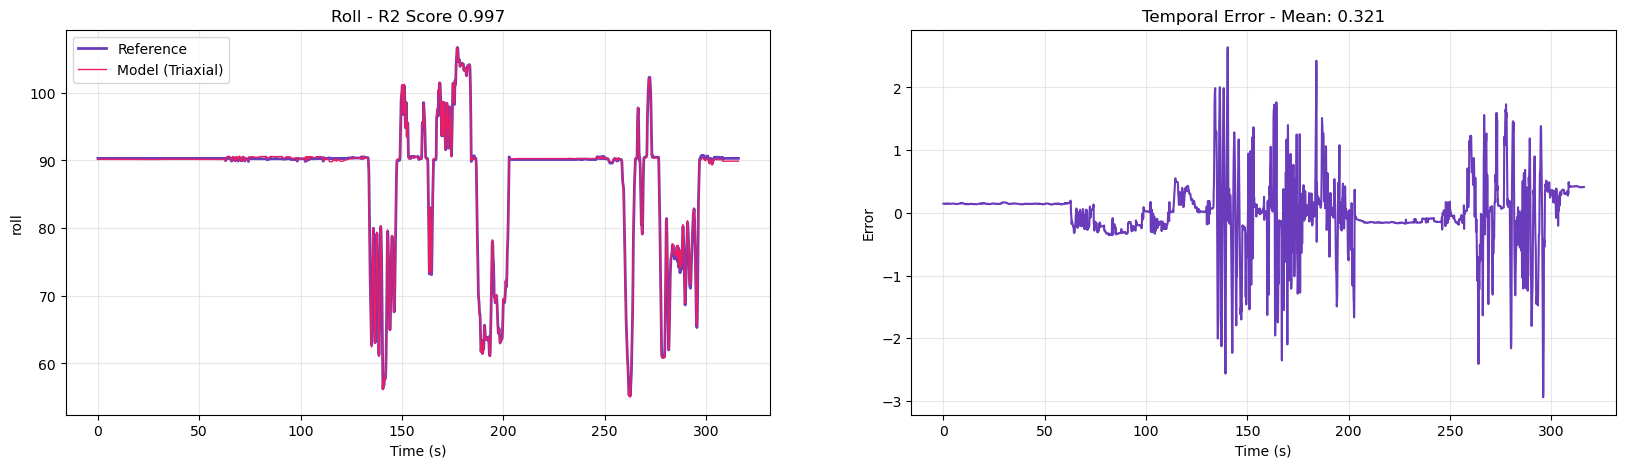

-------------------------------------------------------------------------------- yaw --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.350264,1.916177,2.299893,13.535739,-0.014464,-25.981143,0.748604,2.299893,10.765992,0.374302,13.535739,11.407317,-82.46975


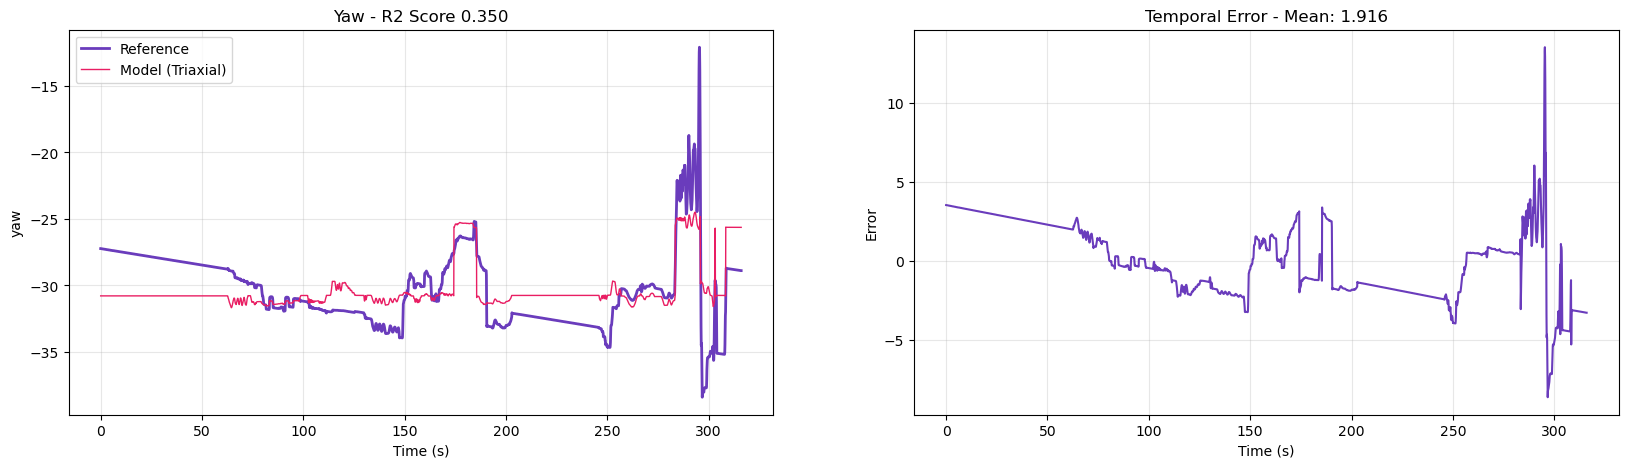

,wx,wy,wz,bias
wx_model,0.885188,-0.173969,0.032762,-0.027669
wy_model,0.072360,0.801398,-0.005378,-0.023961
wz_model,-0.042866,-0.032539,0.788203,0.005883


-------------------------------------------------------------------------------- wx --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.781059,1.435132,3.258188,45.883245,0.885188,-0.027669,0.458559,3.258188,0.230405,0.22928,45.883245,0.956654,2.647542


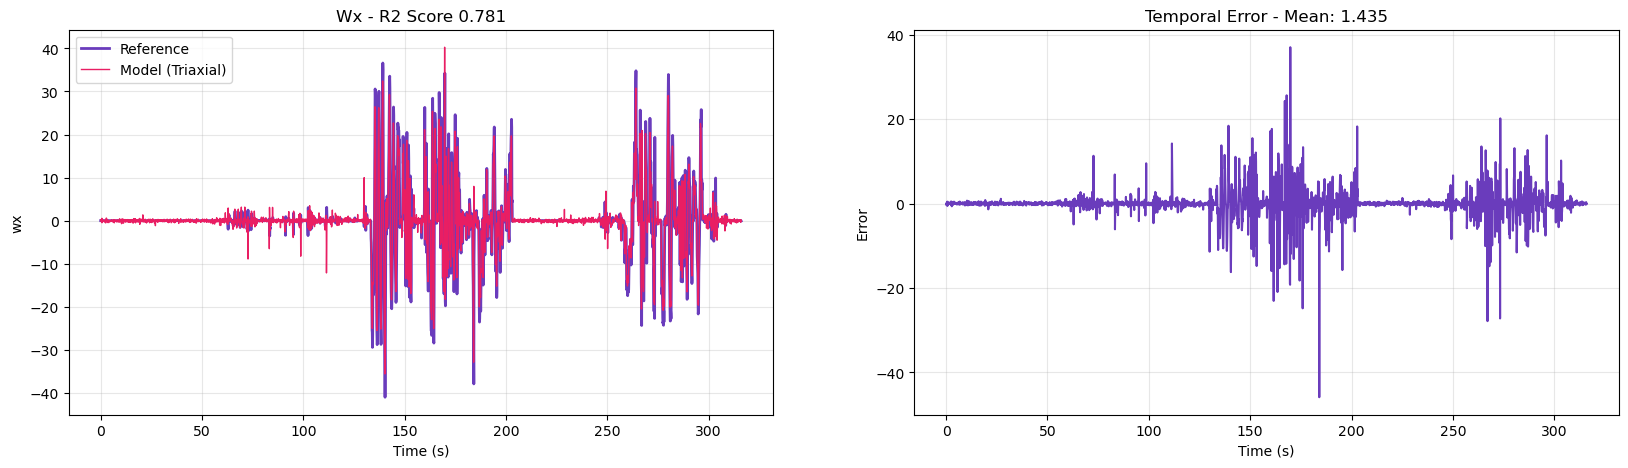

-------------------------------------------------------------------------------- wy --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.675549,0.453811,1.25992,25.364008,0.801398,-0.023961,0.340031,1.25992,0.170253,0.170015,25.364008,0.546284,-2.053187


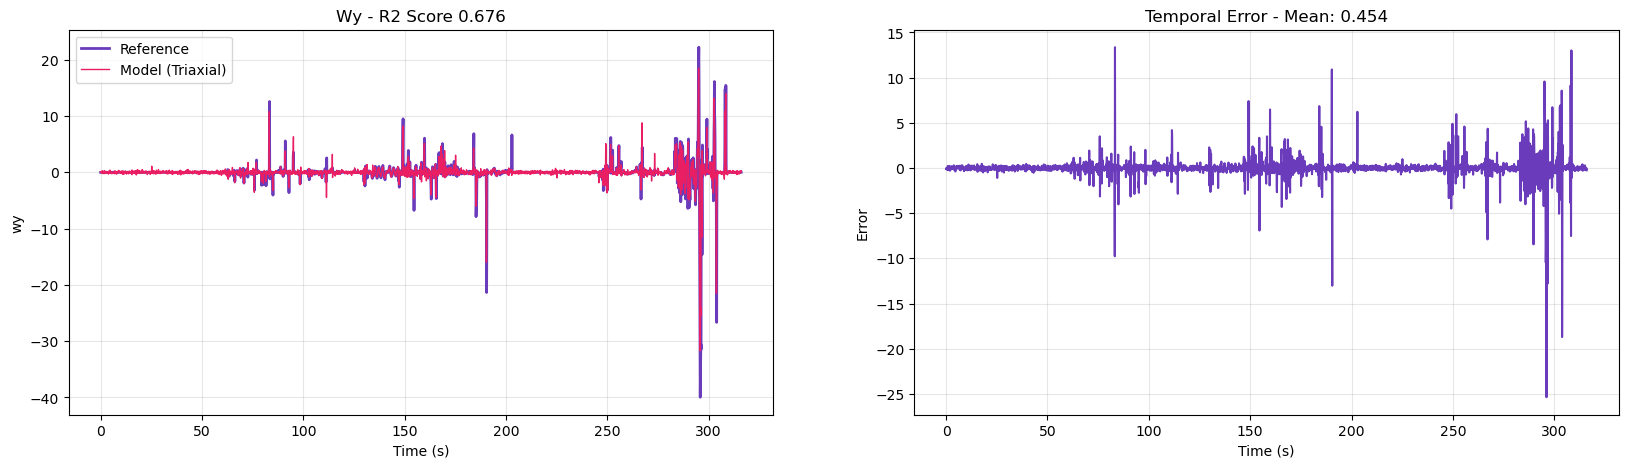

-------------------------------------------------------------------------------- wz --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.603888,1.471296,3.468246,53.444053,0.788203,0.005883,0.437074,3.468246,0.218559,0.218537,53.444053,0.782948,-2.61593


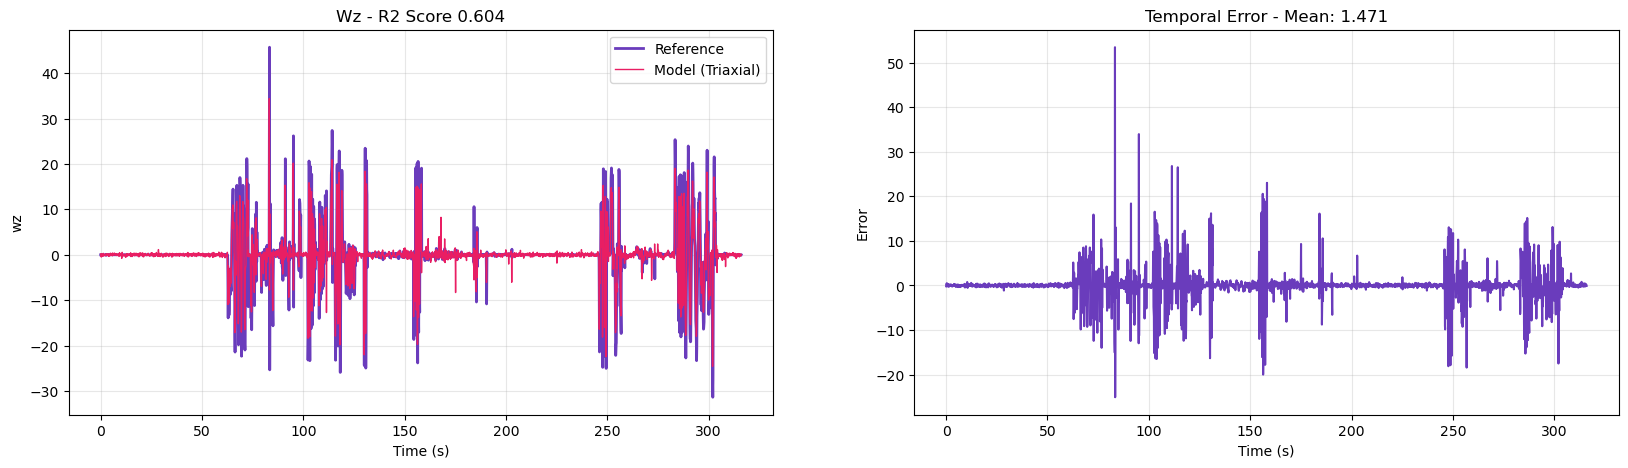

,ax,ay,az,bias
ax_model,0.776046,-0.016738,0.097224,0.883442
ay_model,0.023600,-0.292971,-0.124128,-6.800915
az_model,-0.033050,0.275419,0.865896,-3.028092


-------------------------------------------------------------------------------- ax --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.748277,0.201086,0.439691,7.97037,0.776046,0.883442,0.062045,0.439691,0.134003,0.031022,7.97037,0.335145,0.32443


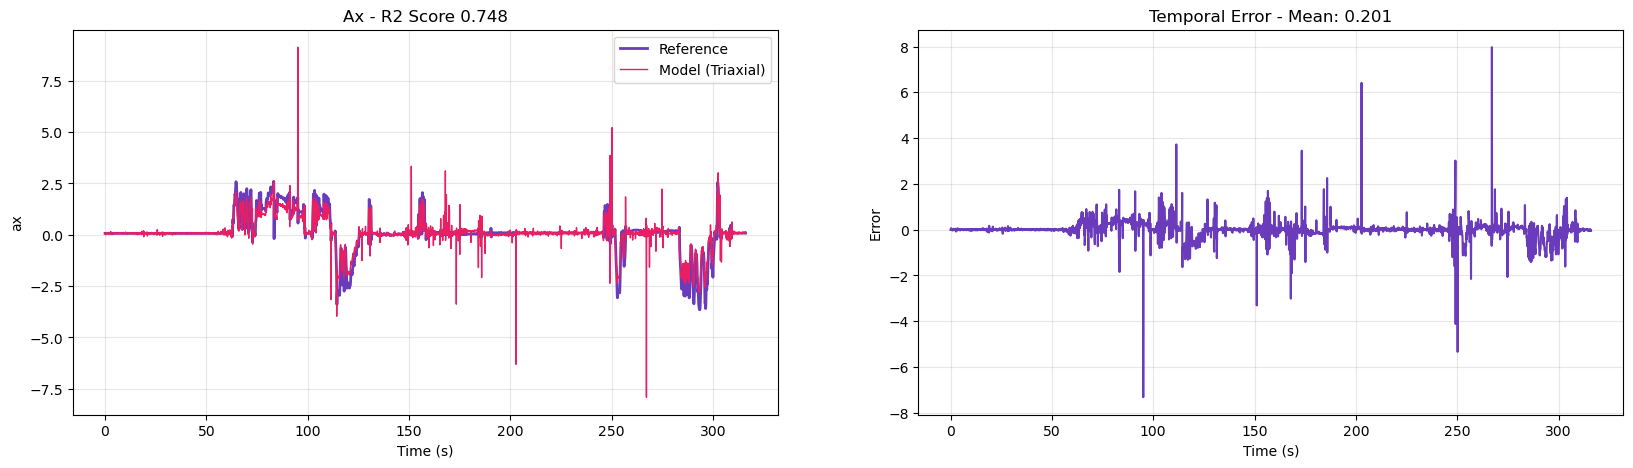

-------------------------------------------------------------------------------- ay --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.556975,0.156727,0.242525,2.670794,-0.292971,-6.800915,0.0224,0.242525,0.069318,0.0112,2.670794,0.152692,-0.036443


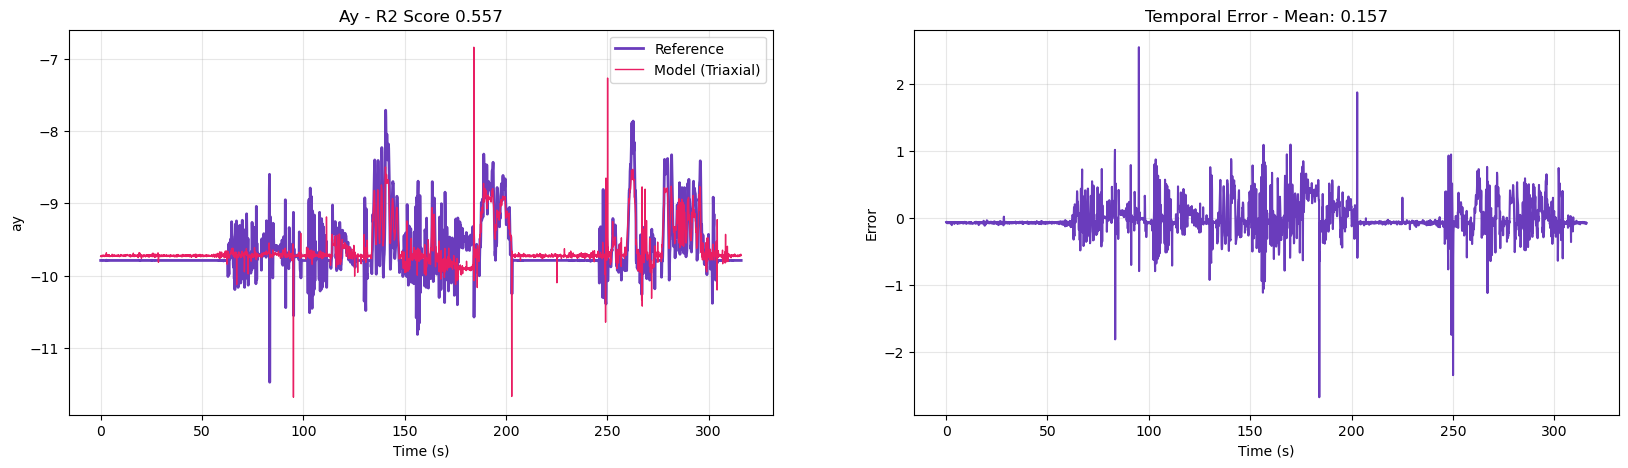

-------------------------------------------------------------------------------- az --------------------------------------------------------------------------------


,r2,mae,rmse,maxError,scaleFactor,bias,precision,rms_dyn,rms_stat,std_stat,accuracy_dyn,accuracy_stat,time_drift
0,0.876536,0.225869,0.517053,10.949104,0.865896,-3.028092,0.100974,0.517053,0.105094,0.050487,10.949104,0.560878,0.264004


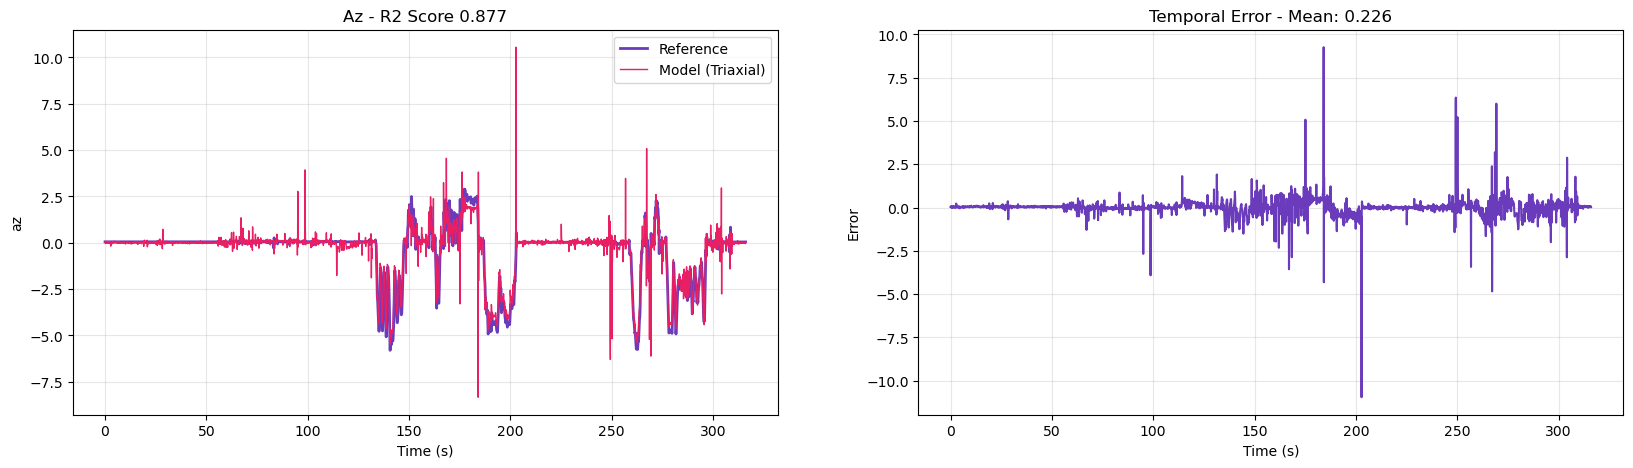

In [325]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar   = rawVar # Ex: 'pitch'
        self.model    = model
        self.calibration = calibration
        self.outputDir   = os.path.join(basePath, 'results', rawVar)
        
        self.axis_idx = model.variables.index(rawVar)
        self.metrics  = model.metrics[rawVar]

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        label   = self.rawVar.capitalize()

        t = self.model.time
        y_ref = self.model.Y[:, self.axis_idx]
        y_mod = self.model.Y_model[:, self.axis_idx]
        err   = self.model.errors[:, self.axis_idx]

        if plotType == 'ref':
            r2_score = self.metrics.get('r2', 1.0)
            ax.plot(t, y_ref, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(t, y_mod, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Amplitude', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido ({r2_score*100:.2f}%)', fontsize=8, fontweight='bold')
        else:
            ax.plot(t, err, color=self.PURPLE_MID, linewidth=0.8)
            ax.set_ylabel('Erro', fontsize=7)
            ax.set_ylim(-max(abs(err)*3.5), max(abs(err)*3.5))
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()
        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)
        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        path = os.path.join(self.outputDir, 'metrics.json')

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        self.exportPlots()
        self.exportMetrics()
        self.exportCalibration()
        return self.outputDir


for label, variables in groups.items():
    model = TriaxialFit(df_dynamic, variables)
    model.update()
    model.display()
    
    for idx, var in enumerate(variables):
        print('-'*80, var, '-'*80)
        df_dynamic['model_' + var] = model.predict(idx)
        df_static['model_' + var]  = df_static[[f'target_{v}' for v in variables]].values @ model.M[idx] + model.B[idx]
        
        cal = CalibrationAnalysis(model, df_dynamic, df_static, var)
        cal.update()
        cal.display()
        model.metrics[var] = cal.metrics
                
        model.plot(idx)
        exporter = ResultExporter('Certificate', var, model)
        exporter.export()